In [ ]:
# Student Performance Analysis
**Tools:** Python, Pandas, Matplotlib, Seaborn, SciPy, scikit-learn  
**Purpose:** Explore drivers of `FinalGrade` (study time, attendance, parental support, etc.) and produce visual + statistical insights.


In [2]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# display options
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
%matplotlib inline


In [5]:
# Cell 4: Load dataset
df = pd.read_csv("student_performance.csv")
print("Rows, Columns:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all'))


Rows, Columns: (98, 7)


,Gender,Age,StudyTime,Attendance,PastFailures,ParentalSupport,FinalGrade
0,M,17,8,92,0,High,85
1,F,16,5,88,0,Medium,78
2,M,18,10,95,1,High,88
3,F,17,3,75,2,Low,65
4,M,16,2,60,3,Low,55


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           98 non-null     object
 1   Age              98 non-null     int64 
 2   StudyTime        98 non-null     int64 
 3   Attendance       98 non-null     int64 
 4   PastFailures     98 non-null     int64 
 5   ParentalSupport  98 non-null     object
 6   FinalGrade       98 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 5.5+ KB


None

,Gender,Age,StudyTime,Attendance,PastFailures,ParentalSupport,FinalGrade
count,98,98.000000,98.000000,98.000000,98.000000,98,98.000000
unique,2,NaN,NaN,NaN,NaN,3,NaN
top,M,NaN,NaN,NaN,NaN,High,NaN
freq,49,NaN,NaN,NaN,NaN,40,NaN
mean,NaN,17.010204,6.775510,84.785714,0.744898,NaN,79.346939
std,NaN,0.805841,2.464304,11.182875,0.922918,NaN,11.097601
min,NaN,16.000000,1.000000,55.000000,0.000000,NaN,50.000000
25%,NaN,16.000000,5.000000,80.000000,0.000000,NaN,74.250000
50%,NaN,17.000000,7.000000,87.000000,0.000000,NaN,80.000000
75%,NaN,18.000000,9.000000,93.000000,1.000000,NaN,88.000000


In [6]:
# Cell 6: quick checks
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique values (categorical):")
print("ParentalSupport:", df['ParentalSupport'].unique())
print("Gender:", df['Gender'].unique())


Missing values per column:
 Gender             0
Age                0
StudyTime          0
Attendance         0
PastFailures       0
ParentalSupport    0
FinalGrade         0
dtype: int64

Duplicate rows: 7

Unique values (categorical):
ParentalSupport: ['High' 'Medium' 'Low']
Gender: ['M' 'F']


In [7]:
# Cell 8: cleaning
# For numeric columns, fill with median; for categoricals, fill with mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Fill numeric NaNs
for c in num_cols:
    if df[c].isnull().any():
        df[c].fillna(df[c].median(), inplace=True)

# Fill categorical NaNs
for c in cat_cols:
    if df[c].isnull().any():
        df[c].fillna(df[c].mode()[0], inplace=True)

# Convert types if needed
df['ParentalSupport'] = df['ParentalSupport'].astype('category')
df['Gender'] = df['Gender'].astype('category')

# Remove duplicates
df.drop_duplicates(inplace=True)

print("After cleaning — Rows, Columns:", df.shape)
display(df.isnull().sum())


After cleaning — Rows, Columns: (91, 7)


Gender             0
Age                0
StudyTime          0
Attendance         0
PastFailures       0
ParentalSupport    0
FinalGrade         0
dtype: int64

In [8]:
# Cell 10: derived columns
df['AttendanceGroup'] = pd.cut(df['Attendance'],
                               bins=[-1, 60, 80, 100],
                               labels=['Low (<=60)','Medium (61-80)','High (81-100)'])

# grade bucket (optional)
df['GradeBucket'] = pd.cut(df['FinalGrade'],
                           bins=[-1,60,70,80,90,100],
                           labels=['F(<=60)','D(61-70)','C(71-80)','B(81-90)','A(91-100)'])

display(df[['Attendance','AttendanceGroup','FinalGrade','GradeBucket']].head())


,Attendance,AttendanceGroup,FinalGrade,GradeBucket
0,92,High (81-100),85,B(81-90)
1,88,High (81-100),78,C(71-80)
2,95,High (81-100),88,B(81-90)
3,75,Medium (61-80),65,D(61-70)
4,60,Low (<=60),55,F(<=60)


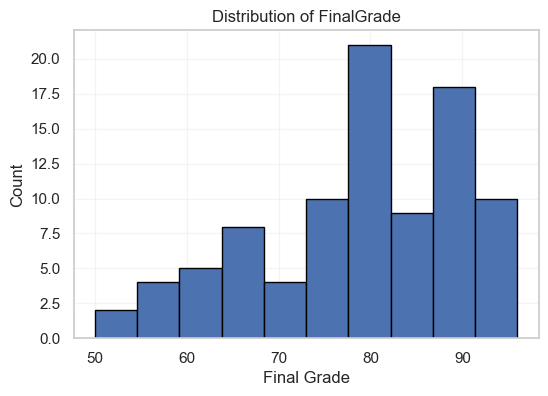

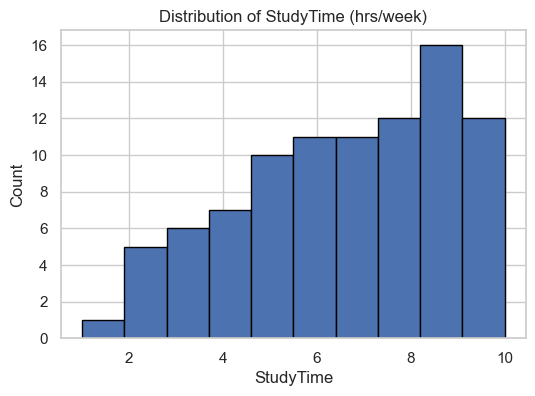

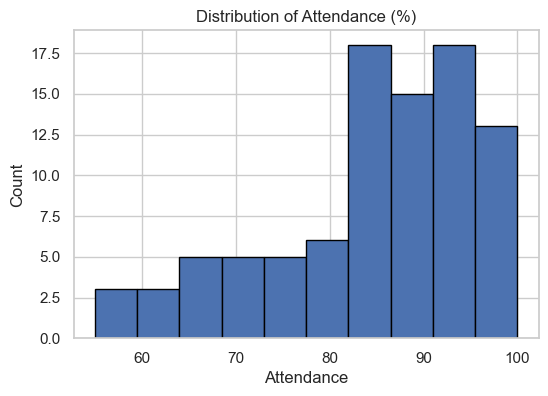

In [9]:
# Cell 12: histograms
plt.figure(figsize=(6,4))
plt.hist(df['FinalGrade'], bins=10, edgecolor='black')
plt.title('Distribution of FinalGrade')
plt.xlabel('Final Grade')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['StudyTime'], bins=10, edgecolor='black')
plt.title('Distribution of StudyTime (hrs/week)')
plt.xlabel('StudyTime')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['Attendance'], bins=10, edgecolor='black')
plt.title('Distribution of Attendance (%)')
plt.xlabel('Attendance')
plt.ylabel('Count')
plt.show()


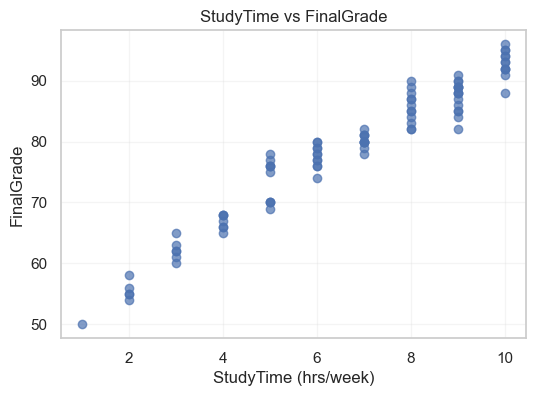

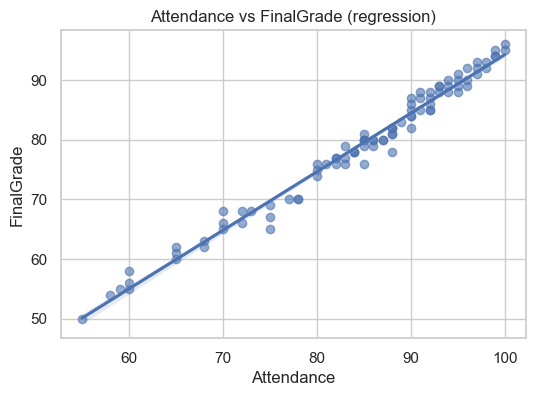

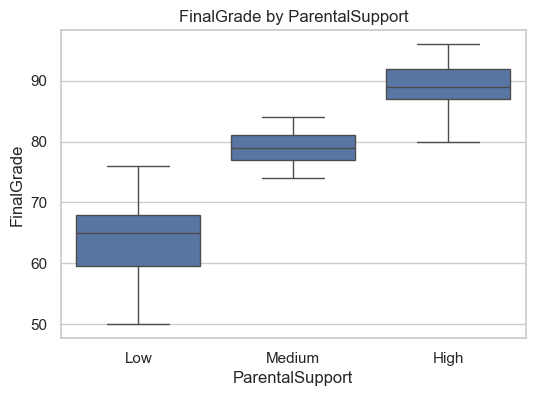

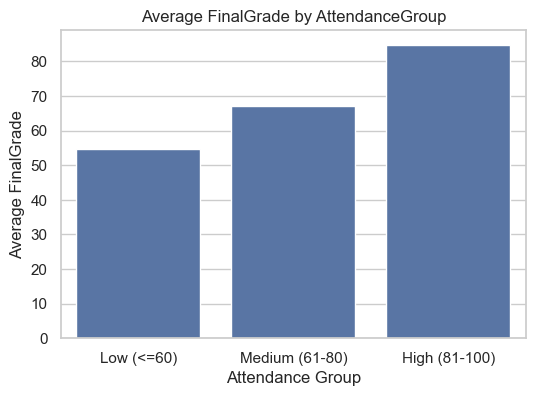

In [10]:
# Cell 14: relationship plots
plt.figure(figsize=(6,4))
plt.scatter(df['StudyTime'], df['FinalGrade'], alpha=0.7)
plt.title('StudyTime vs FinalGrade')
plt.xlabel('StudyTime (hrs/week)')
plt.ylabel('FinalGrade')
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6,4))
sns.regplot(x='Attendance', y='FinalGrade', data=df, scatter_kws={'alpha':0.6})
plt.title('Attendance vs FinalGrade (regression)')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='ParentalSupport', y='FinalGrade', data=df,
            order=['Low','Medium','High'])
plt.title('FinalGrade by ParentalSupport')
plt.show()

# Average grade by attendance group
avg_by_att = df.groupby('AttendanceGroup', observed=False)['FinalGrade'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='AttendanceGroup', y='FinalGrade', data=avg_by_att)
plt.title('Average FinalGrade by AttendanceGroup')
plt.xlabel('Attendance Group')
plt.ylabel('Average FinalGrade')
plt.show()


Pearson correlation with FinalGrade:
FinalGrade      1.000000
Attendance      0.990973
StudyTime       0.972475
Age             0.389767
PastFailures   -0.905132
Name: FinalGrade, dtype: float64


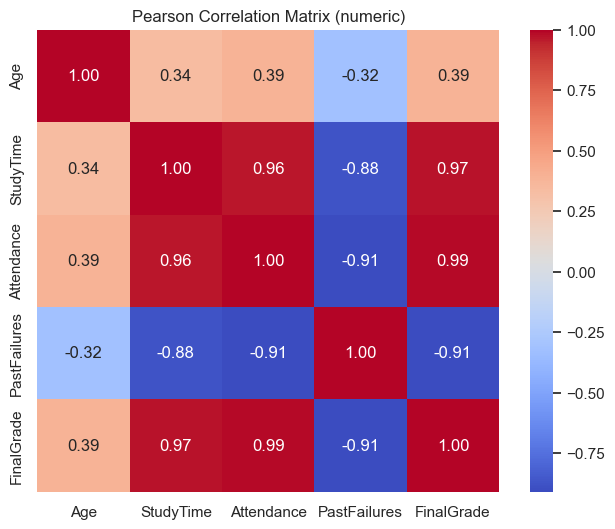

In [11]:
# Cell 16: correlations
numeric_df = df.select_dtypes(include=[np.number])
pearson_corr = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')

print("Pearson correlation with FinalGrade:")
print(pearson_corr['FinalGrade'].sort_values(ascending=False))

plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Pearson Correlation Matrix (numeric)')
plt.show()


In [12]:
# Cell 18: ANOVA for AttendanceGroup
groups = [grp['FinalGrade'].values for name, grp in df.groupby('AttendanceGroup', observed=True) if not grp.empty]
group_names = [name for name, grp in df.groupby('AttendanceGroup', observed=True) if not grp.empty]
print("Groups:", group_names)

if len(groups) > 1:
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")
else:
    print("Not enough groups for ANOVA.")

# t-test: High vs Low
high = df[df['AttendanceGroup']=='High (81-100)']['FinalGrade']
low = df[df['AttendanceGroup']=='Low (<=60)']['FinalGrade']

if len(high) > 1 and len(low) > 1:
    t_stat, p_t = stats.ttest_ind(high, low, equal_var=False)
    print(f"T-test High vs Low: t={t_stat:.3f}, p={p_t:.5f}")
else:
    print("Not enough samples in High or Low group for t-test.")


Groups: ['Low (<=60)', 'Medium (61-80)', 'High (81-100)']
ANOVA F-statistic: 146.702, p-value: 0.00000
T-test High vs Low: t=23.187, p=0.00000


In [13]:
# Cell 20: Cohen's d
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na-1)*sa + (nb-1)*sb) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / pooled

if len(high) > 1 and len(low) > 1:
    d = cohens_d(high, low)
    print(f"Cohen's d (High - Low): {d:.3f}")
else:
    print("Not enough samples for Cohen's d.")


Cohen's d (High - Low): 5.384


In [15]:
!pip install -U scikit-learn



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Cell 22: prepare features
X = df[['StudyTime','Attendance','PastFailures','ParentalSupport','Gender']].copy()
X = pd.get_dummies(X, drop_first=True)  # one-hot encode categorical
y = df['FinalGrade']

# Split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
preds = lr.predict(X_test)

# Metrics (compatible with all sklearn versions)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.3f}")
print(f"R^2: {r2:.3f}")

# Coefficients (feature importance)
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lr.coef_}).sort_values(by='coefficient', ascending=False)
display(coef_df)


RMSE: 1.341
R^2: 0.989


,feature,coefficient
0,StudyTime,0.722813
1,Attendance,0.722600
2,PastFailures,0.339456
5,Gender_M,-0.265202
4,ParentalSupport_Medium,-2.069179
3,ParentalSupport_Low,-3.555709


In [18]:
# Cell 24: save figures (recreate key plots and save)
import os
os.makedirs("figures", exist_ok=True)

# 1. attendance vs grade regression plot
plt.figure(figsize=(6,4))
sns.regplot(x='Attendance', y='FinalGrade', data=df, scatter_kws={'alpha':0.6})
plt.title('Attendance vs FinalGrade')
plt.savefig("figures/attendance_vs_finalgrade.png", bbox_inches='tight')
plt.close()

# 2. studytime vs grade scatter
plt.figure(figsize=(6,4))
plt.scatter(df['StudyTime'], df['FinalGrade'], alpha=0.7)
plt.title('StudyTime vs FinalGrade')
plt.xlabel('StudyTime (hrs/week)')
plt.ylabel('FinalGrade')
plt.savefig("figures/studytime_vs_finalgrade.png", bbox_inches='tight')
plt.close()

# 3. correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Pearson Correlation Matrix')
plt.savefig("figures/correlation_heatmap.png", bbox_inches='tight')
plt.close()

print("Saved figures to ./figures/")


Saved figures to ./figures/


In [20]:
# Cell 26: auto summary builder (editable)
pearson_with_grade = pearson_corr['FinalGrade'].drop('FinalGrade').sort_values(ascending=False)
print("Top numeric correlations with FinalGrade:")
display(pearson_with_grade)

# ANOVA/T-test results printed earlier — include them here by recomputing
# Recompute quick stats for summary
att_mean = df.groupby('AttendanceGroup', observed=True)['FinalGrade'].mean()
print("\nAverage FinalGrade by AttendanceGroup:")
display(att_mean)

# Short recommendations (editable)
print("\nRecommendations (suggested):")
print("- Monitor and improve attendance: students in High attendance group have higher mean grades.")
print("- Support students with low study time via time-management workshops and tutoring.")
print("- Provide targeted interventions for students with past failures (mentoring, remedial classes).")
print("- Engage parents — parental support relates to higher median grades (see boxplot).")


Top numeric correlations with FinalGrade:


Attendance      0.990973
StudyTime       0.972475
Age             0.389767
PastFailures   -0.905132
Name: FinalGrade, dtype: float64


Average FinalGrade by AttendanceGroup:


AttendanceGroup
Low (<=60)        54.666667
Medium (61-80)    67.250000
High (81-100)     84.800000
Name: FinalGrade, dtype: float64


Recommendations (suggested):
- Monitor and improve attendance: students in High attendance group have higher mean grades.
- Support students with low study time via time-management workshops and tutoring.
- Provide targeted interventions for students with past failures (mentoring, remedial classes).
- Engage parents — parental support relates to higher median grades (see boxplot).
